## **Model evaluation with Argo floats**


In this script we will look:
- Defining a region for the analysis.
- Collecting Argo floats observations from this region.
- Plotting a TS-diagram model and obs together

Modified from [this script](https://github.com/ACCESS-Community-Hub/coastal-commons/blob/main/recipes/roms/model_eval_argo.ipynb)  

In [1]:
import xarray as xr
import gsw
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import LineString, Polygon
from matplotlib.path import Path
from dask.distributed import Client
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45833,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36565,Total threads: 1
Dashboard: /proxy/38427/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:43437,


In [2]:
#Model specific information.
#note that we are currently calling coordinates (lat_var, lon_var etc) in each step using this notation: lon_var= model_args[model]['lon_var']
#we could simplify by using cf_xarray https://cf-xarray.readthedocs.io/en/latest/index.html
model_args = {
              "roms": {"temp_var": "temp",
                       "salt_var": "salt",
                       "lat_var": "lat_rho",
                       "lon_var": "lon_rho",
                       "time_var": 'ocean_time',
                       "z_var": "s_rho",
                       "z_inx": -1,
                       "spatial_dims":('eta_rho', 'xi_rho'),
                       "temp_file_name":'/g/data/yj27/users/cgk561/30yr_run_1993_2023_CK/output/roms_his_08[34567]*',
                       "salt_file_name":'/g/data/yj27/users/cgk561/30yr_run_1993_2023_CK/output/roms_his_08[34567]*',


             },
              "mom6": { "temp_var": "thetao",
                        "salt_var": "so",
                       "lat_var": "yh",
                       "lon_var": "xh",
                       'time_var': 'time',
                       "z_var": "z_l",
                       "z_inx": 0,
                       "spatial_dims":('yh', 'xh'),
                       "temp_file_name": "/g/data/av17/access-nri/rOM3/superaus/v20260619/expt08_outputs3/output*/access-om3.mom6.3d.thetao.1day.mean*.nc",
                       "salt_file_name": "/g/data/av17/access-nri/rOM3/superaus/v20260619/expt08_outputs3/output*/access-om3.mom6.3d.so.1day.mean*.nc",

              }
}

In [3]:
#Spefifying the region and models we want to investigate:
#lon_min = 145
#lon_max = 165
#lat_min = -42
#lat_max = -24

lon_min = 154
lon_max = 156
lat_min = -32.5
lat_max = -31
year = '2013'
models = ['roms', 'mom6']

In [4]:
# Reading the model output

# Glob will list all the HIS files and sorted will sort them out ascending.
# Reading the data. Adjust the path according to where your data is and its name.
# OSTIA data is in Kelvin, so we convert it to Celsius.
# This step takes a while
temp ={}
salt ={}
for model in models:
    print(model)
    tempvarname = model_args[model]['temp_var']
    saltvarname = model_args[model]['salt_var']
    tempfiles = model_args[model]['temp_file_name']
    saltfiles = model_args[model]['salt_file_name']
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    temp[model] = xr.open_mfdataset(tempfiles, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[tempvarname]
    salt[model] = xr.open_mfdataset(saltfiles, parallel=True, decode_timedelta=True,chunks={time_var: 1, lat_var: 'auto', lon_var: 'auto'} )[saltvarname]


roms
mom6


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/dask/_task_spec.py:763: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  return self.func(*new_argspec, **kwargs)
/

In [5]:
# Reading Argo floats

# Listing and sorting Argo files
files_argo = sorted(glob('/g/data/yj27/data/obs/easycora/eaus/PR_PF/*nc'))

print('Checking Argo files: ', files_argo[:5])

# Reading all the files available. Can't use xarray because the dimensions don't match
# Storing in a dictionary, by year.
argo = dict()
for ff in files_argo:
    year = ff.split('/')[-1].split('_')[2]
    argo[year] = xr.open_dataset(ff) 


argo.keys()

Checking Argo files:  ['/g/data/yj27/data/obs/easycora/eaus/PR_PF/ECO_DMQCGL01_2001_PR_PF.nc', '/g/data/yj27/data/obs/easycora/eaus/PR_PF/ECO_DMQCGL01_2002_PR_PF.nc', '/g/data/yj27/data/obs/easycora/eaus/PR_PF/ECO_DMQCGL01_2003_PR_PF.nc', '/g/data/yj27/data/obs/easycora/eaus/PR_PF/ECO_DMQCGL01_2004_PR_PF.nc', '/g/data/yj27/data/obs/easycora/eaus/PR_PF/ECO_DMQCGL01_2005_PR_PF.nc']


dict_keys(['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'])

In [6]:
#go through each argo float. If it is in the domain then append to new dataset
#find the equivilent model profile
DA = argo[year]
is_inside = list()
argoregion = list()
for LON, LAT, TEMP, PSAL, TIME in zip(DA.LONGITUDE.values, DA.LATITUDE.values, DA.TEMP.values, DA.PSAL.values, DA.TIME.values):
    coord = np.array([[LON, LAT]])
    if ( (LAT < lat_max) & (LAT > lat_min)  & (LON >lon_min) &  (LON<lon_max) ):
        is_inside.append([coord[0][0], coord[0][1]])
        argoregion.append([LON,LAT, TEMP, PSAL, TIME])


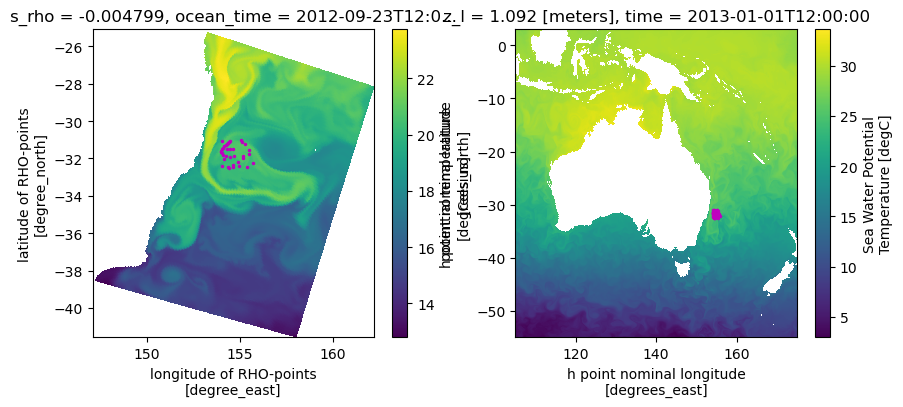

In [7]:
#plotting on model domains
ncols = len(model_args)
fig, ax = plt.subplots(ncols=ncols, figsize=(ncols*5, 4))
n = 0
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']
    z_var = model_args[model]['z_var']
    z_inx = model_args[model]['z_inx']
    temp[model].isel({time_var:0, z_var:z_inx}).plot(ax=ax[n], x=lon_var, y=lat_var)
    ax[n].plot(np.array(is_inside)[:, 0], np.array(is_inside)[:, 1], '.m', markersize=3)
    n = n+1


In [8]:
#subsetting for each model
#Subsettng by lat and lon 
tempsub = {}
saltsub = {}
for model in models:
    lat_var= model_args[model]['lat_var']
    lon_var= model_args[model]['lon_var']
    time_var = model_args[model]['time_var']

    #subsetting by lat/lon
    mask = ( (temp[model][lat_var] < lat_max) & (temp[model][lat_var] > lat_min)  & (temp[model][lon_var] >lon_min) &  (temp[model][lon_var]<lon_max)).compute()
    tempsub[model] = temp[model].where(mask)
    saltsub[model] = salt[model].where(mask)

    
    #subsetting by time - we want 1 year, and every 5 days (as every day is too large of a dataset)
    tempsub[model]  = tempsub[model].sel({time_var: slice("2013-01-01", "2013-12-31")})
    tempsub[model] = tempsub[model].drop_duplicates(time_var, keep='first')
    tempsub[model]  = tempsub[model].resample(**{time_var:"5D"}).nearest(tolerance="1D")

    saltsub[model]  = saltsub[model].sel({time_var: slice("2013-01-01", "2013-12-31")})
    saltsub[model] =  saltsub[model].drop_duplicates(time_var, keep='first')
    saltsub[model]  = saltsub[model].resample(**{time_var:"5D"}).nearest(tolerance="1D")
    

In [9]:
def water_density():
    tempL = np.linspace(0, 30, 156)
    saltL = np.linspace(33.5, 37, 156)
    Tg, Sg = np.meshgrid(tempL,saltL)
    sigma_theta = gsw.sigma0(Sg, Tg)
    return Tg, Sg, sigma_theta
Tg, Sg, sigma_theta = water_density()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


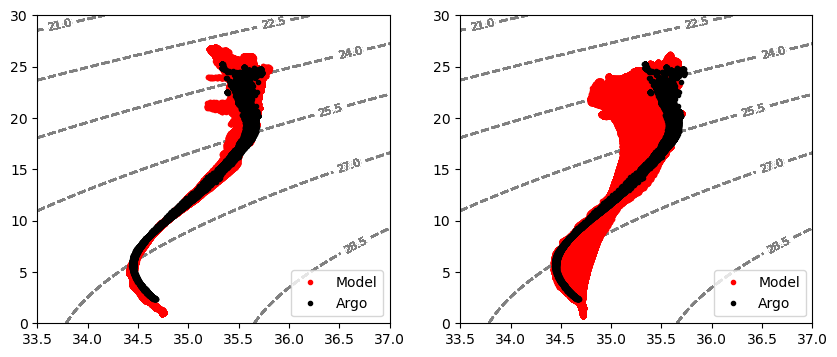

In [10]:
#getting rid of NaNs and plotting
ncols = len(model_args)
fig, ax = plt.subplots(ncols=ncols, figsize=(ncols*5, 4))
n = 0
for model in models:
    spatial_dims= model_args[model]['spatial_dims']
    tempvec = tempsub[model].stack(points=spatial_dims).dropna(dim="points").data.ravel()
    saltvec = saltsub[model].stack(points=spatial_dims).dropna(dim="points").data.ravel()
    ax[n].plot(saltvec, tempvec, ".", color="r")
    for _, _, TEMP, PSAL, _ in argoregion:
            ax[n].plot(PSAL, TEMP, '.', color='k')
            cs = ax[n].contour(Sg, Tg, sigma_theta, colors='grey', zorder=1, linestyles='dashed')
            cl = ax[n].clabel(cs, fontsize=8, inline=True, fmt='%.1f')  
            ax[n].legend(['Model', 'Argo']);
    n=n+1